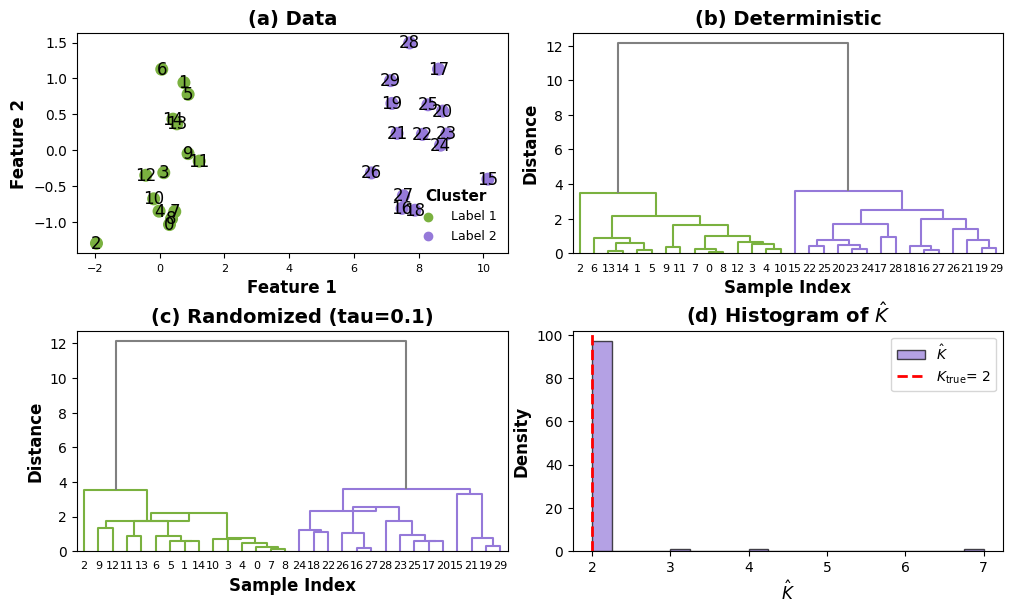

In [2]:
import random
import sys, os
sys.path.append(os.path.abspath('../src'))
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from utils import *
import sklearn.cluster as cluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
#import matplotlib as mpl
from matplotlib.colors import ListedColormap
import seaborn as sns
from find_best_K import find_best_K_F, generate_alpha_list
from collections import Counter
import glob

np.random.seed(0)
random.seed(0)
rng = np.random.default_rng(0)
tau = 0.1

raw_dir = os.path.join("../results", "raw", "fig1")
all_files = sorted(glob.glob(os.path.join(raw_dir, "findK_results_tau005_K*.npz")))
Ks = []
X = y = None
true_K = 2

for f in all_files:
    data = np.load(f)
    Ks.extend(data['Ks'])
    if X is None:  # only keep one representative dataset
        X = data['X']
        y = data['y']
        true_K = int(data['true_K'])
    data.close()

Ks = np.array(Ks)
#print(f"Loaded {len(all_files)} batch files, total {len(Ks)} trials combined.")

#print(Ks)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))


manual_colors = ["#ff924c", "#9579d9", "#7ab13f"]
cluster_0 = y[0]
cluster_10 = y[10]
cluster_23 = y[23]

color_dict = {
    cluster_0: "#ff924c",
    cluster_10: "#7ab13f",
    cluster_23: "#9579d9"
}

unique_labels = np.unique(y)
remaining_clusters = [lab for lab in unique_labels if lab not in color_dict]
remaining_colors = [c for c in manual_colors if c not in color_dict.values()]
for lab, col in zip(remaining_clusters, remaining_colors):
    color_dict[lab] = col

point_colors = [color_dict[label] for label in y]

axes[0,0].scatter(X[:, 0], X[:, 1], s=70, c=point_colors)
axes[0,0].set_title('(a) Data', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[0,0].tick_params(axis='x', labelsize=8)
axes[0,0].tick_params(axis='y', labelsize=10)
for i in range(len(X)):
    axes[0,0].annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='center', va='center')

for label_val in unique_labels:
    axes[0,0].scatter([], [], color=color_dict[label_val], label=f"Label {int(label_val)}")
legend = axes[0,0].legend(
    title="Cluster",
    loc="lower right",
    fontsize=9,
    title_fontsize=11,
    frameon=False
)
legend.get_title().set_fontweight('bold')

axes[1, 1].hist(Ks, bins=20, density=False, alpha=0.7,
                color="#9579d9", edgecolor="black", label=r"$\hat{K}$")
axes[1, 1].axvline(x=true_K, color='red', linestyle='--',
                   linewidth=2, label=fr"$K_{{\mathrm{{true}}}}$= {true_K}")
axes[1, 1].set_xlabel("$\hat{K}$", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Density", fontsize=12, fontweight='bold')
axes[1, 1].set_title(r"(d) Histogram of $\hat{K}$", fontsize=14, fontweight='bold')
#axes[1, 0].grid(True, linestyle="--", alpha=0.5)
axes[1, 1].legend(fontsize=10)

model = cluster.AgglomerativeClustering(n_clusters=true_K, linkage='complete')
labels_sklearn = model.fit_predict(X)
Z = linkage(X, method='complete')

target_points = [0, 10, 23]
target_colors = ["#ff924c", "#7ab13f", "#9579d9"]
cluster_color_map = {labels_sklearn[i]: c for i, c in zip(target_points, target_colors)}

all_clusters = np.unique(labels_sklearn)
unused_colors = [c for c in target_colors if c not in cluster_color_map.values()]
for c in all_clusters:
    if c not in cluster_color_map:
        cluster_color_map[c] = unused_colors.pop(0) if unused_colors else "gray"


def link_color_func(node_id):
    n_samples = len(labels_sklearn)
    if node_id < n_samples:
        return cluster_color_map[labels_sklearn[node_id]]
    else:
        left = int(Z[node_id - n_samples, 0])
        right = int(Z[node_id - n_samples, 1])
        left_color = link_color_func(left)
        right_color = link_color_func(right)
        return left_color if left_color == right_color else "gray"


dendrogram(
    Z,
    color_threshold=0,
    above_threshold_color="gray",
    link_color_func=link_color_func,
    ax=axes[0,1],
)
axes[0,1].set_title("(b) Deterministic", fontsize=14, fontweight='bold')
axes[0,1].set_xlabel("Sample Index", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("Distance", fontsize=12, fontweight='bold')
axes[0,1].tick_params(axis='x', labelsize=8)
axes[0,1].tick_params(axis='y', labelsize=10)
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)

model_r = AgglomerativeClustering(X, tau=tau, n_clusters=true_K, linkage="complete", random_state=42)
model_r.fit(dendrogram=True)
#print(model_r.K_clusters)
#print(model_r.existing_clusters_log)
model_r.plot_dendrogram(ax=axes[1,0], show=False, save_fig=False, manual_color=True)
axes[1,0].set_title(f"(c) Randomized (tau={tau})", fontsize=14, fontweight='bold')


plt.tight_layout(pad=0.2, w_pad=0.3)
plt.show()


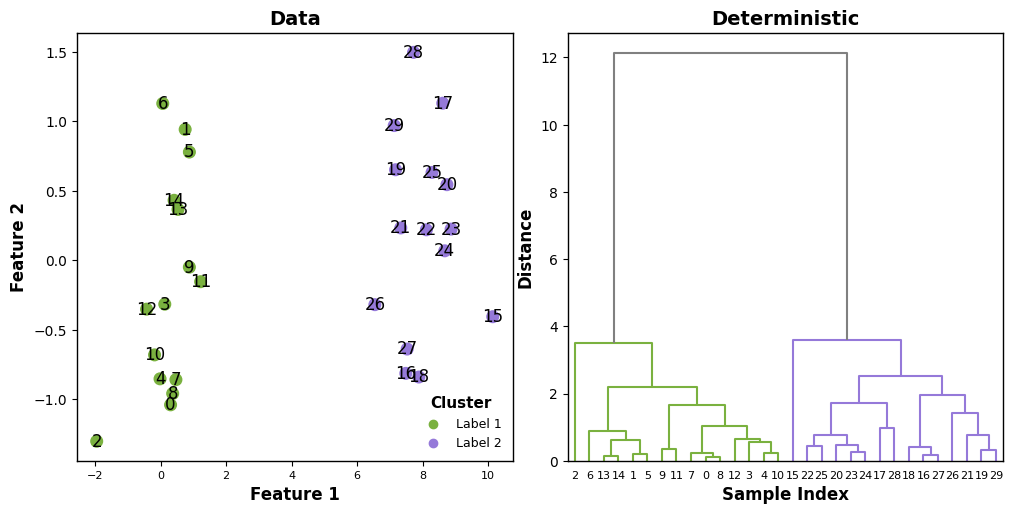

In [3]:
import matplotlib as mpl
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.grid": False,
})

np.random.seed(0)
random.seed(0)
rng = np.random.default_rng(0)
tau = 0.1
raw_dir = os.path.join("../results", "raw", "fig1")
all_files = sorted(glob.glob(os.path.join(raw_dir, "findK_results_tau005_K*.npz")))
Ks = []
X = y = None
true_K = 2

for f in all_files:
    data = np.load(f)
    Ks.extend(data['Ks'])
    if X is None:  # only keep one representative dataset
        X = data['X']
        y = data['y']
        true_K = int(data['true_K'])
    data.close()

Ks = np.array(Ks)
#print(f"Loaded {len(all_files)} batch files, total {len(Ks)} trials combined.")

#print(Ks)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

manual_colors = ["#ff924c", "#9579d9", "#7ab13f"]
cluster_0 = y[0]
cluster_10 = y[10]
cluster_23 = y[23]

color_dict = {
    cluster_0: "#ff924c",
    cluster_10: "#7ab13f",
    cluster_23: "#9579d9"
}

unique_labels = np.unique(y)
remaining_clusters = [lab for lab in unique_labels if lab not in color_dict]
remaining_colors = [c for c in manual_colors if c not in color_dict.values()]
for lab, col in zip(remaining_clusters, remaining_colors):
    color_dict[lab] = col

point_colors = [color_dict[label] for label in y]


axes[0].scatter(X[:, 0], X[:, 1], s=70, c=point_colors)
axes[0].set_title('Data', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].tick_params(axis='y', labelsize=10)
for i in range(len(X)):
    axes[0].annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='center', va='center')

for label_val in unique_labels:
    axes[0].scatter([], [], color=color_dict[label_val], label=f"Label {int(label_val)}")
legend = axes[0].legend(
    title="Cluster",
    loc="lower right",
    fontsize=9,
    title_fontsize=11,
    frameon=False
)
legend.get_title().set_fontweight('bold')
'''
axes[1, 1].hist(Ks, bins=20, density=False, alpha=0.7,
                color="#9579d9", edgecolor="black", label=r"$\hat{K}$")
axes[1, 1].axvline(x=true_K, color='red', linestyle='--',
                   linewidth=2, label=fr"$K_{{\mathrm{{true}}}}$= {true_K}")
axes[1, 1].set_xlabel("$\hat{K}$", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Density", fontsize=12, fontweight='bold')
axes[1, 1].set_title(r"(d) Histogram of $\hat{K}$", fontsize=14, fontweight='bold')
#axes[1, 0].grid(True, linestyle="--", alpha=0.5)
axes[1, 1].legend(fontsize=10)


model_r = AgglomerativeClustering(X, tau=tau, n_clusters=true_K, linkage="complete", random_state=42)
model_r.fit(dendrogram=True)
#print(model_r.K_clusters)
#print(model_r.existing_clusters_log)
model_r.plot_dendrogram(ax=axes[1,0], show=False, save_fig=False, manual_color=True)
axes[1,0].set_title(f"(c) Randomized (tau={tau})", fontsize=14, fontweight='bold')
'''

model = cluster.AgglomerativeClustering(n_clusters=true_K, linkage='complete')
labels_sklearn = model.fit_predict(X)
Z = linkage(X, method='complete')

target_points = [0, 10, 23]
target_colors = ["#ff924c", "#7ab13f", "#9579d9"]
cluster_color_map = {labels_sklearn[i]: c for i, c in zip(target_points, target_colors)}

all_clusters = np.unique(labels_sklearn)
unused_colors = [c for c in target_colors if c not in cluster_color_map.values()]
for c in all_clusters:
    if c not in cluster_color_map:
        cluster_color_map[c] = unused_colors.pop(0) if unused_colors else "gray"


def link_color_func(node_id):
    n_samples = len(labels_sklearn)
    if node_id < n_samples:
        return cluster_color_map[labels_sklearn[node_id]]
    else:
        left = int(Z[node_id - n_samples, 0])
        right = int(Z[node_id - n_samples, 1])
        left_color = link_color_func(left)
        right_color = link_color_func(right)
        return left_color if left_color == right_color else "gray"


dendrogram(
    Z,
    color_threshold=0,
    above_threshold_color="gray",
    link_color_func=link_color_func,
    ax=axes[1],
)
axes[1].set_title("Deterministic", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Sample Index", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Distance", fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', labelsize=8)
axes[1].tick_params(axis='y', labelsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)


plt.tight_layout(pad=0.2, w_pad=0.3)
plt.savefig(
    "/Users/judydw/Desktop/slides-figs/fig1.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


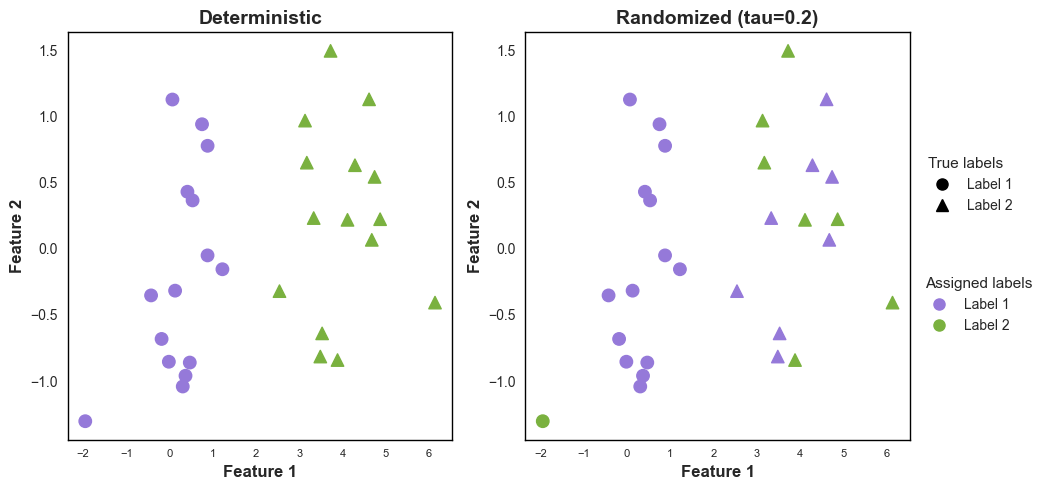

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
delta = 4
sigma = 1
true_K = 2
n = 30
n_each = n//true_K
master_seed = 42
rng = np.random.default_rng(master_seed)
X, y = generate_data_barbers(n_each, delta, sigma, n_clusters=true_K, true_mean=False, rng=rng)
def kclusters_to_labels(K_clusters, n):
    labels = np.empty(n, dtype=int)
    for k, node in enumerate(K_clusters):
        labels[np.asarray(node.points, dtype=int)] = k
    return labels

manual_colors = ["#7ab13f", "#9579d9"]

def build_color_map_from_targets(labels_pred, target_points=(0, 10, 23), palette=manual_colors):
    target_points = [i for i in target_points if i < len(labels_pred)]
    target_colors = palette[:len(target_points)]
    cmap = {labels_pred[i]: c for i, c in zip(target_points, target_colors)}
    unused = [c for c in palette if c not in cmap.values()]
    for lab in np.unique(labels_pred):
        if lab not in cmap:
            cmap[lab] = unused.pop(0) if unused else "gray"
    return cmap

def plot_true_shape_pred_color(ax, X, y_true, labels_pred, title, color_map, marker_map):
    point_colors = [color_map[l] for l in labels_pred]

    for t in np.unique(y_true):
        idx = (y_true == t)
        ax.scatter(
            X[idx, 0], X[idx, 1],
            s=80,
            c=np.array(point_colors, dtype=object)[idx],
            marker=marker_map[t]
        )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('Feature 2', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=10)

    true_handles = [
        Line2D([0], [0], marker=marker_map[t], color='k',
               linestyle='None', markersize=8,
               label=f"Label {int(t)}")
        for t in np.unique(y_true)
    ]

    pred_handles = [
        Line2D([0], [0], marker='o', color=color_map[lab],
               linestyle='None', markersize=8,
               label=f"Label {int(lab+1)}")
        for lab in np.unique(labels_pred)
    ]

    return true_handles, pred_handles

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

y_true = np.asarray(y).astype(int)
uniq_true = np.unique(y_true)
markers = ['o', '^']
marker_map = {t: markers[i % len(markers)] for i, t in enumerate(uniq_true)}

all_true_handles = None
all_pred_handles = None

taus = [0.0, 0.2]
for j, tau_val in enumerate(taus):
    model_r = AgglomerativeClustering(
        X, tau=tau_val, n_clusters=true_K,
        linkage="complete", random_state=42
    )
    model_r.fit()
    labels_pred = kclusters_to_labels(model_r.K_clusters, n=X.shape[0])

    color_map = build_color_map_from_targets(
        labels_pred, target_points=(0, 10, 23), palette=manual_colors
    )
    
    if tau_val != 0:
        true_h, pred_h = plot_true_shape_pred_color(
            axes[j], X, y_true, labels_pred,
            f"Randomized (tau={tau_val})",
            color_map, marker_map
        )
    else:
        true_h, pred_h = plot_true_shape_pred_color(
            axes[j], X, y_true, labels_pred,
            f"Deterministic",
            color_map, marker_map
        )

    if all_true_handles is None:
        all_true_handles = true_h
    if all_pred_handles is None:
        all_pred_handles = pred_h
fig.legend(
    handles=all_true_handles,
    labels=[h.get_label() for h in all_true_handles],
    title="True labels",
    title_fontsize=11,
    fontsize=10,
    frameon=False,
    loc="center right",
    bbox_to_anchor=(1.03, 0.62),
    alignment="left"
)

fig.legend(
    handles=all_pred_handles,
    labels=[h.get_label() for h in all_pred_handles],
    title="Assigned labels",
    title_fontsize=11,
    fontsize=10,
    frameon=False,
    loc="center right",
    bbox_to_anchor=(1.05, 0.38),
    alignment="left"
)

plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.savefig(
    "/Users/judydw/Desktop/slides-figs/fig2.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

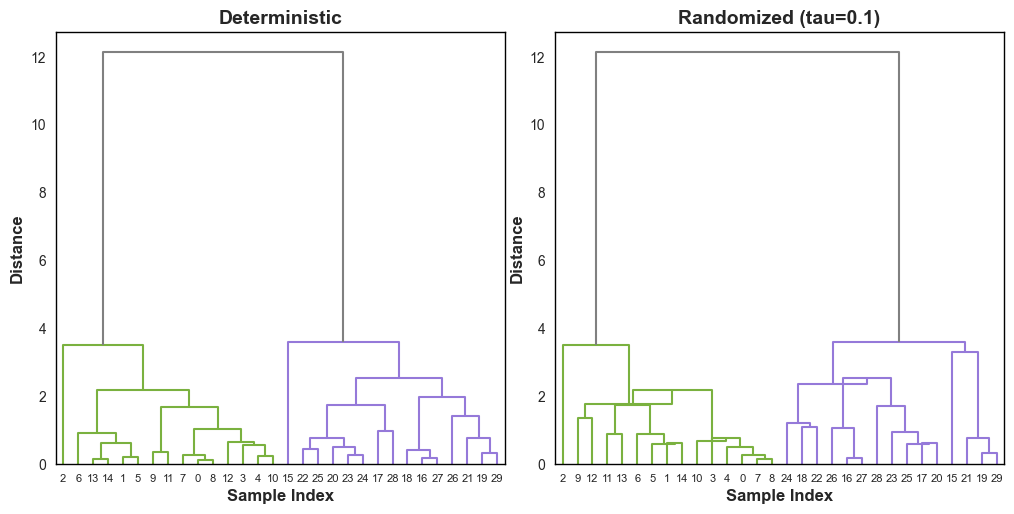

In [93]:
np.random.seed(0)
random.seed(0)
rng = np.random.default_rng(0)
tau = 0.1

raw_dir = os.path.join("../results", "raw", "fig1")
all_files = sorted(glob.glob(os.path.join(raw_dir, "findK_results_tau005_K*.npz")))
Ks = []
X = y = None
true_K = 2

for f in all_files:
    data = np.load(f)
    Ks.extend(data['Ks'])
    if X is None:  # only keep one representative dataset
        X = data['X']
        y = data['y']
        true_K = int(data['true_K'])
    data.close()

Ks = np.array(Ks)
#print(f"Loaded {len(all_files)} batch files, total {len(Ks)} trials combined.")

#print(Ks)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

manual_colors = ["#ff924c", "#9579d9", "#7ab13f"]
cluster_0 = y[0]
cluster_10 = y[10]
cluster_23 = y[23]

color_dict = {
    cluster_0: "#ff924c",
    cluster_10: "#7ab13f",
    cluster_23: "#9579d9"
}

unique_labels = np.unique(y)
remaining_clusters = [lab for lab in unique_labels if lab not in color_dict]
remaining_colors = [c for c in manual_colors if c not in color_dict.values()]
for lab, col in zip(remaining_clusters, remaining_colors):
    color_dict[lab] = col

point_colors = [color_dict[label] for label in y]

'''
axes[0].scatter(X[:, 0], X[:, 1], s=50, c=point_colors)
axes[0].set_title('(a) Data', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].tick_params(axis='y', labelsize=10)
for i in range(len(X)):
    axes[0].annotate(str(i), (X[i, 0], X[i, 1]), fontsize=10, ha='center', va='center')

for label_val in unique_labels:
    axes[0].scatter([], [], color=color_dict[label_val], label=f"Label {int(label_val)}")
legend = axes[0].legend(
    title="Cluster",
    loc="lower right",
    fontsize=9,
    title_fontsize=11,
    frameon=False
)
legend.get_title().set_fontweight('bold')

axes[1, 1].hist(Ks, bins=20, density=False, alpha=0.7,
                color="#9579d9", edgecolor="black", label=r"$\hat{K}$")
axes[1, 1].axvline(x=true_K, color='red', linestyle='--',
                   linewidth=2, label=fr"$K_{{\mathrm{{true}}}}$= {true_K}")
axes[1, 1].set_xlabel("$\hat{K}$", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Density", fontsize=12, fontweight='bold')
axes[1, 1].set_title(r"(d) Histogram of $\hat{K}$", fontsize=14, fontweight='bold')
#axes[1, 0].grid(True, linestyle="--", alpha=0.5)
axes[1, 1].legend(fontsize=10)



'''

model = cluster.AgglomerativeClustering(n_clusters=true_K, linkage='complete')
labels_sklearn = model.fit_predict(X)
Z = linkage(X, method='complete')

target_points = [0, 10, 23]
target_colors = ["#ff924c", "#7ab13f", "#9579d9"]
cluster_color_map = {labels_sklearn[i]: c for i, c in zip(target_points, target_colors)}

all_clusters = np.unique(labels_sklearn)
unused_colors = [c for c in target_colors if c not in cluster_color_map.values()]
for c in all_clusters:
    if c not in cluster_color_map:
        cluster_color_map[c] = unused_colors.pop(0) if unused_colors else "gray"


def link_color_func(node_id):
    n_samples = len(labels_sklearn)
    if node_id < n_samples:
        return cluster_color_map[labels_sklearn[node_id]]
    else:
        left = int(Z[node_id - n_samples, 0])
        right = int(Z[node_id - n_samples, 1])
        left_color = link_color_func(left)
        right_color = link_color_func(right)
        return left_color if left_color == right_color else "gray"


dendrogram(
    Z,
    color_threshold=0,
    above_threshold_color="gray",
    link_color_func=link_color_func,
    ax=axes[0],
)
axes[0].set_title("Deterministic", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Sample Index", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Distance", fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

model_r = AgglomerativeClustering(X, tau=tau, n_clusters=true_K, linkage="complete", random_state=42)
model_r.fit(dendrogram=True)
#print(model_r.K_clusters)
#print(model_r.existing_clusters_log)
model_r.plot_dendrogram(ax=axes[1], show=False, save_fig=False, manual_color=True)
axes[1].set_title(f"Randomized (tau={tau})", fontsize=14, fontweight='bold')
plt.tight_layout(pad=0.2, w_pad=0.3)
plt.savefig(
    "/Users/judydw/Desktop/slides-figs/fig3.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


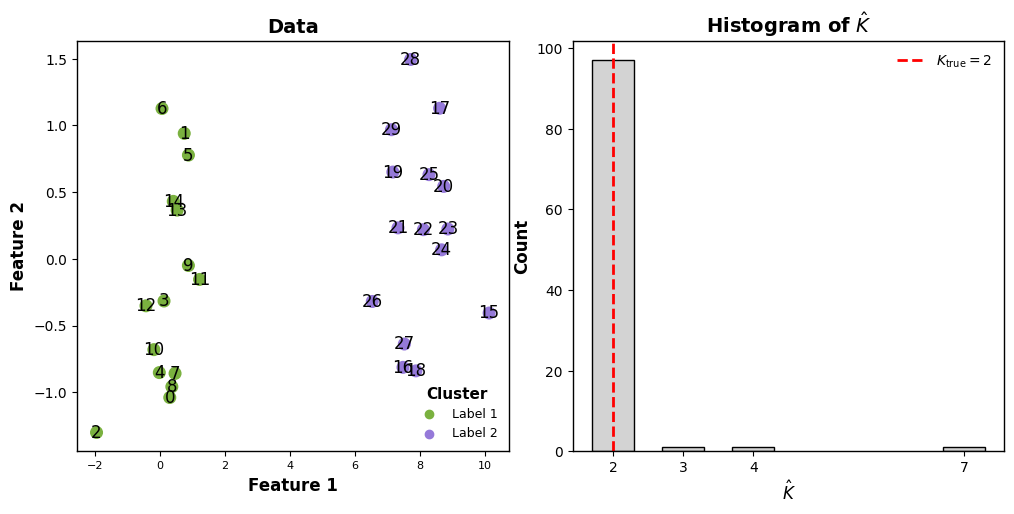

In [4]:
import matplotlib as mpl
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.grid": False,
})
np.random.seed(0)
random.seed(0)
rng = np.random.default_rng(0)
tau = 0.1

raw_dir = os.path.join("../results", "raw", "fig1")
all_files = sorted(glob.glob(os.path.join(raw_dir, "findK_results_tau005_K*.npz")))
Ks = []
X = y = None
true_K = 2

for f in all_files:
    data = np.load(f)
    Ks.extend(data['Ks'])
    if X is None:  # only keep one representative dataset
        X = data['X']
        y = data['y']
        true_K = int(data['true_K'])
    data.close()

Ks = np.array(Ks)
#print(f"Loaded {len(all_files)} batch files, total {len(Ks)} trials combined.")

#print(Ks)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)

manual_colors = ["#ff924c", "#9579d9", "#7ab13f"]
cluster_0 = y[0]
cluster_10 = y[10]
cluster_23 = y[23]

color_dict = {
    cluster_0: "#ff924c",
    cluster_10: "#7ab13f",
    cluster_23: "#9579d9"
}

unique_labels = np.unique(y)
remaining_clusters = [lab for lab in unique_labels if lab not in color_dict]
remaining_colors = [c for c in manual_colors if c not in color_dict.values()]
for lab, col in zip(remaining_clusters, remaining_colors):
    color_dict[lab] = col

point_colors = [color_dict[label] for label in y]


axes[0].scatter(X[:, 0], X[:, 1], s=70, c=point_colors)
axes[0].set_title('Data', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].tick_params(axis='y', labelsize=10)
for i in range(len(X)):
    axes[0].annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='center', va='center')

for label_val in unique_labels:
    axes[0].scatter([], [], color=color_dict[label_val], label=f"Label {int(label_val)}")
legend = axes[0].legend(
    title="Cluster",
    loc="lower right",
    fontsize=9,
    title_fontsize=11,
    frameon=False
)
legend.get_title().set_fontweight('bold')

k_vals, counts = np.unique(Ks, return_counts=True)

axes[1].bar(
    k_vals,
    counts,
    width=0.6,               
    color="lightgray",
    edgecolor="black"
)

axes[1].axvline(
    x=true_K,
    color="red",
    linestyle="--",
    linewidth=2,
    label=fr"$K_{{\mathrm{{true}}}} = {true_K}$"
)

axes[1].set_xticks(k_vals)
axes[1].set_xlabel(r"$\hat{K}$", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count", fontsize=12, fontweight="bold")
axes[1].set_title(r"Histogram of $\hat{K}$", fontsize=14, fontweight="bold")

axes[1].legend(frameon=False)


'''

model = cluster.AgglomerativeClustering(n_clusters=true_K, linkage='complete')
labels_sklearn = model.fit_predict(X)
Z = linkage(X, method='complete')

target_points = [0, 10, 23]
target_colors = ["#ff924c", "#7ab13f", "#9579d9"]
cluster_color_map = {labels_sklearn[i]: c for i, c in zip(target_points, target_colors)}

all_clusters = np.unique(labels_sklearn)
unused_colors = [c for c in target_colors if c not in cluster_color_map.values()]
for c in all_clusters:
    if c not in cluster_color_map:
        cluster_color_map[c] = unused_colors.pop(0) if unused_colors else "gray"


def link_color_func(node_id):
    n_samples = len(labels_sklearn)
    if node_id < n_samples:
        return cluster_color_map[labels_sklearn[node_id]]
    else:
        left = int(Z[node_id - n_samples, 0])
        right = int(Z[node_id - n_samples, 1])
        left_color = link_color_func(left)
        right_color = link_color_func(right)
        return left_color if left_color == right_color else "gray"


dendrogram(
    Z,
    color_threshold=0,
    above_threshold_color="gray",
    link_color_func=link_color_func,
    ax=axes[0],
)
axes[0].set_title("Deterministic", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Sample Index", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Distance", fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

model_r = AgglomerativeClustering(X, tau=tau, n_clusters=true_K, linkage="complete", random_state=42)
model_r.fit(dendrogram=True)
#print(model_r.K_clusters)
#print(model_r.existing_clusters_log)
model_r.plot_dendrogram(ax=axes[1], show=False, save_fig=False, manual_color=True)
axes[1].set_title(f"Randomized (tau={tau})", fontsize=14, fontweight='bold')
'''
plt.tight_layout(pad=0.2, w_pad=0.3)
plt.savefig(
    "/Users/judydw/Desktop/slides-figs/fig4.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


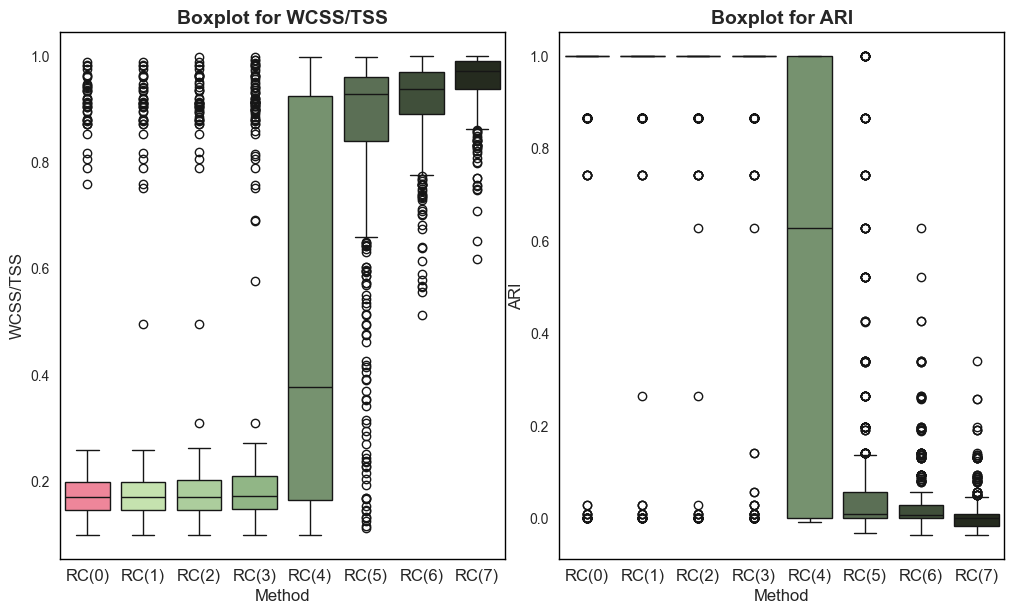

In [68]:
K=2
df_wcss = pd.read_csv(f"../results/raw/df_wcss_{K}.csv")
df_ari =  pd.read_csv(f"../results/raw/df_ari_{K}.csv")
df_recovery =  pd.read_csv(f"../results/raw/df_recovery_{K}.csv")

# --- aggregate recovery probability ---
df_recovery = df_recovery.groupby(['Tau', 'Method'])['Recovery'].mean().reset_index()
df_recovery.rename(columns={'Recovery': 'Recovery Probability'}, inplace=True)

subset_tau = [0,0.025,0.05,0.1,0.25,0.5,1,5]
#labels = ["Naive","RAC(0.025)","RAC(0.05)", "RAC(0.1)", "RAC(0.25)", "RAC(0.5)", "RAC(1)","RAC(5)"]
labels = ["RC(0)", "RC(1)", "RC(2)", "RC(3)", "RC(4)", "RC(5)", "RC(6)", "RC(7)"]
rename_map = dict(zip(subset_tau, labels))

wcss_sub = df_wcss[df_wcss['Tau'].isin(subset_tau)].copy()
wcss_sub["method"] = wcss_sub["Tau"].map(rename_map)
ari_sub = df_ari[df_ari['Tau'].isin(subset_tau)].copy()
ari_sub["method"] = ari_sub["Tau"].map(rename_map)
recovery_sub = df_recovery[df_recovery['Tau'].isin(subset_tau)].copy()
rec_x_pos = range(len(subset_tau))

custom_colors = ["#FF758F", "#BFE8A4", "#9CBE86", "#7B9669", "#5B704D", "#3D4C33",  "#222B1B"]
custom_colors = ["#FF758F","#C4EAA7", "#A9D595", "#8DBE7E","#729869", "#587450", "#3F5237", "#252D1D"]
#custom_colors = ['#cc5e72', '#99ba83', '#7d986b', '#627854', '#495a3e', '#313d29', '#1b2216']
fig, axes = plt.subplots(1, 2, figsize=(10,6))
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)
sns.boxplot(data=wcss_sub, x='method', y='WCSS/TSS', hue='method',
            palette=custom_colors, ax=axes[0])
axes[0].set_title('Boxplot for WCSS/TSS', fontsize=14, fontweight='bold')
axes[0].set_xlabel("Method", fontsize=12)
axes[0].set_ylabel("WCSS/TSS", fontsize=12)
axes[0].tick_params(axis='x', labelsize=12)

sns.boxplot(data=ari_sub, x='method', y='ARI', hue='method', palette=custom_colors, ax = axes[1])
axes[1].set_title('Boxplot for ARI', fontsize=14, fontweight='bold')
axes[1].set_xlabel("Method", fontsize=12)
axes[1].set_ylabel("ARI", fontsize=12)
axes[1].tick_params(axis='x', labelsize=12)

'''
axes[2].plot(rec_x_pos, recovery_sub['Recovery Probability'], marker='o', color="#222B1B", linewidth=2)
axes[2].set_xticks(rec_x_pos)
axes[2].set_xticklabels(labels)
axes[2].tick_params(axis='x', labelsize=7)
axes[2].set_xlabel("Method", fontsize=12)
axes[2].set_ylabel("Recovery Probability", fontsize=12)
axes[2].set_title("Line Plot for Recovery Probability", fontsize=14, fontweight='bold')
'''



plt.tight_layout(pad=0.2, w_pad=0.3)
plt.savefig(
    "/Users/judydw/Desktop/slides-figs/sec2.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()



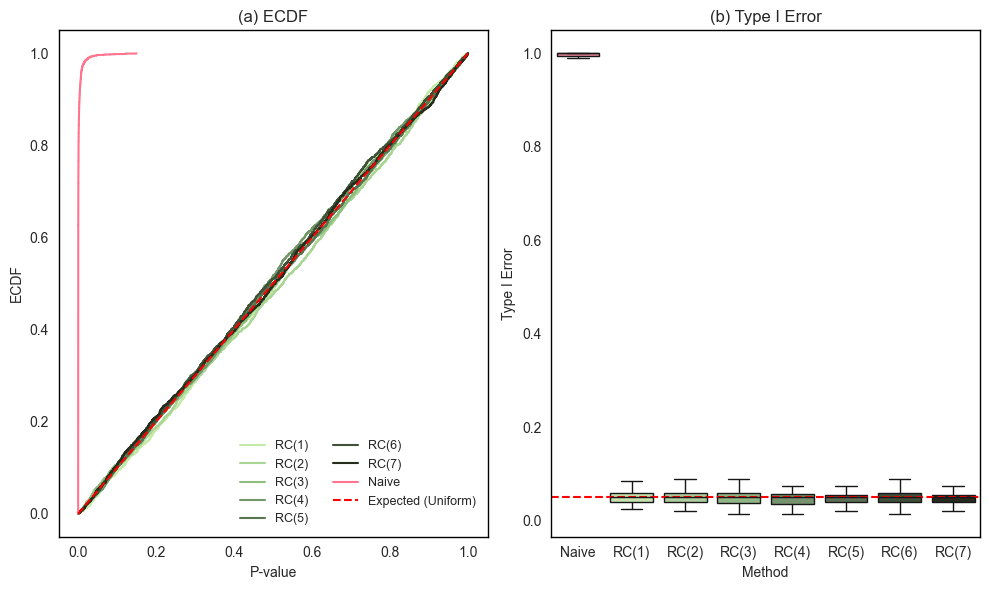

In [69]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Ks = [2]
alpha = 0.05
linkage = "complete"

green_shades = ["#C4EAA7", "#A9D595", "#8DBE7E", "#729869",
                "#587450", "#3F5237", "#252D1D"]
color_map = {"Naive": "#FF758F", "Expected (Uniform)": "#FF0000"}

def plot_ecdf(values, label, color, ax):
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where="post", label=label, color=color)

def _is_float(s):
    try:
        float(s)
        return True
    except:
        return False


# ---------- figure ----------
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
ax_ecdf, ax_type1 = axes
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)
# ---------- load data ----------
K = Ks[0]
df = pd.read_csv(f"../results/raw/fig4/pval_validity_randomized_K{K}.csv")
type1 = pd.read_csv(f"../results/raw/fig4/type1_error_randomized_K{K}.csv")

# ---------- (a) ECDF ----------
tau_cols = [c for c in df.columns if c.startswith("tau=")]
naive = df["naive"].dropna().to_numpy()

for i, col in enumerate(tau_cols):
    plot_ecdf(
        df[col].dropna().to_numpy(),
        label=f"RC({i+1})",
        color=green_shades[i],
        ax=ax_ecdf
    )

plot_ecdf(naive, "Naive", color_map["Naive"], ax=ax_ecdf)
ax_ecdf.plot([0, 1], [0, 1], "--",
             color=color_map["Expected (Uniform)"],
             label="Expected (Uniform)")

ax_ecdf.set_xlabel("P-value")
ax_ecdf.set_ylabel("ECDF")
ax_ecdf.set_title("(a) ECDF")
ax_ecdf.grid(True, linestyle="--", alpha=0.5)

# ---------- legend INSIDE ECDF ----------
ax_ecdf.legend(
    loc="lower right",
    fontsize=9,
    frameon=False,
    ncol=2
)

# ---------- (b) Type I Error ----------
df_tau = type1.copy()
df_tau.loc[df_tau["Type"].str.lower() == "naive", "Tau"] = 0.0
df_tau["Group"] = df_tau["Tau"].astype(float).map(lambda x: f"{x:g}")

order = sorted(
    [g for g in df_tau["Group"].unique() if _is_float(g)],
    key=float
)

palette = {"0": color_map["Naive"]}
for t, c in zip([float(o) for o in order if float(o) != 0], green_shades):
    palette[f"{t:g}"] = c

df_tau["Group"] = pd.Categorical(
    df_tau["Group"],
    categories=order,
    ordered=True
)

sns.boxplot(
    data=df_tau,
    x="Group",
    y="Type I Error",
    hue="Group",
    order=order,
    palette=palette,
    showfliers=False,
    legend=False,
    ax=ax_type1
)

labels = ["Naive" if float(g) == 0 else f"RC({i})"
          for i, g in enumerate(order)]
ticks = np.arange(len(labels))
ax_type1.set_xticks(ticks)
ax_type1.set_xticklabels(labels)

ax_type1.axhline(alpha, linestyle="--", color="red")
ax_type1.set_xlabel("Method")
ax_type1.set_ylabel("Type I Error")
ax_type1.set_title("(b) Type I Error")
ax_type1.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    "/Users/judydw/Desktop/slides-figs/sec3fig3.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


Plotting K=2, linkage=complete
Plotting K=2, linkage=average
Plotting K=2, linkage=single
Plotting K=2, linkage=minimax


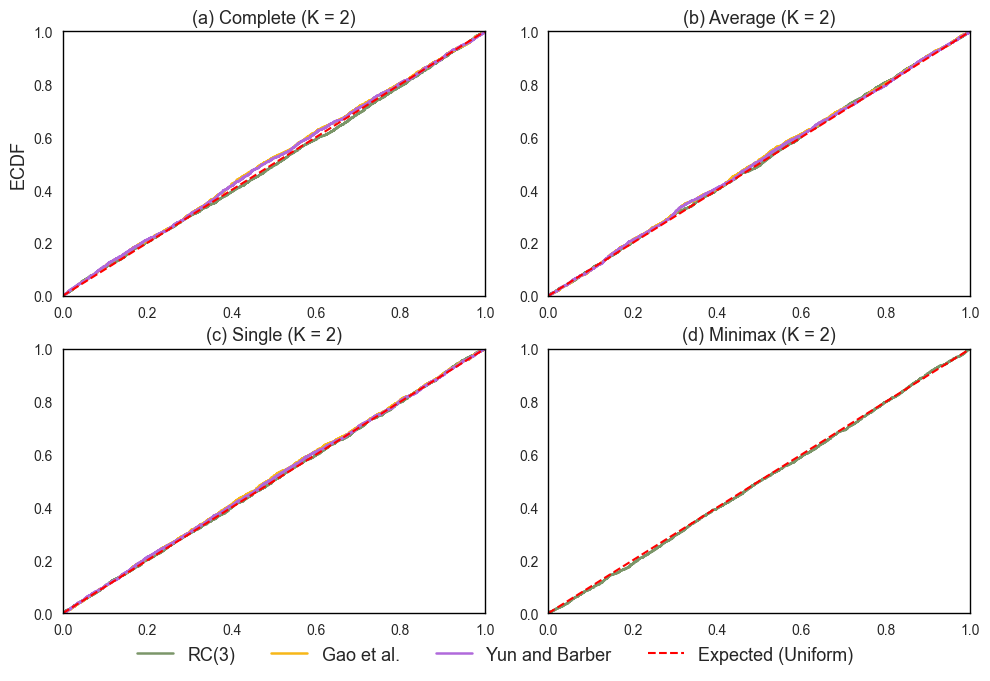

In [70]:
alpha = 0.05
tau = 0.1
output_dir = os.path.join("../results/figures")
os.makedirs(output_dir, exist_ok=True)

linkages = ["complete", "average", "single", "minimax"]
Ks = [2]

# === colors ===
color_map = {
    "RAC": "#7B9669",                   # green
    "Yun and Barber": "#B069DB",                # purple
     r"Gao et al.": "#F7B718",  # yellow
     r"Gao et al.($\widehat{\sigma}_{\text{clustered}}$)": "#8e1b01", # dark red
    "Expected (Uniform)": "#FF0000"     # red dashed line
}

def plot_ecdf(values, label, color, ax, lw=1.8):
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where='post', label=label, color=color, linewidth=lw)

# === Figure setup (2×4 grid, share axes) ===
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)
axes = axes.flatten()
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)
all_labels = []
handles_for_legend = []

for row_idx, K in enumerate(Ks):
    for col_idx, linkage in enumerate(linkages):
        i = row_idx * len(linkages) + col_idx
        ax = axes[i]
        print(f"Plotting K={K}, linkage={linkage}")

        # --- Randomized (RAC) ---
        rand_path = f"../results/raw/fig5_2000/pval_validity_randomized_K{K}_{linkage}.csv"
        if os.path.exists(rand_path):
            df_rand = pd.read_csv(rand_path)
            col = f"tau={tau}"
            if col in df_rand.columns:
                h = ax.step(
                    np.sort(df_rand[col].dropna()),
                    np.arange(1, df_rand[col].dropna().size + 1) / df_rand[col].dropna().size,
                    where="post", color=color_map["RAC"], linewidth=1.8,
                    label="RC(3)" if "RAC" not in all_labels else None
                )[0]
                if "RAC" not in all_labels:
                    handles_for_legend.append(h)
                    all_labels.append("RAC")

        # --- Gao & Barber (skip minimax) ---
        if linkage != "minimax":
            gb_path = f"../results/raw/fig5_2000/pval_valid_gao&barber_K{K}_{linkage}.csv"
            if os.path.exists(gb_path):
                df_gb = pd.read_csv(gb_path)
                label_map = {
                    "Gao (sigma_all)": r"Gao et al.",
                    "Gao (sigma_clustered)": r"Gao et al.($\widehat{\sigma}_{\text{clustered}}$)",
                    "Barber": "Yun and Barber"
                }

                for colname in df_gb.columns:
                    if colname == "Gao (sigma_clustered)":
                        continue
                    label = label_map.get(colname, colname)
                    color = color_map.get(label, "gray")
                    h = ax.step(
                        np.sort(df_gb[colname].dropna()),
                        np.arange(1, df_gb[colname].dropna().size + 1) / df_gb[colname].dropna().size,
                        where="post", color=color, linewidth=1.8,
                        label=label if label not in all_labels else None
                    )[0]
                    if label not in all_labels:
                        handles_for_legend.append(h)
                        all_labels.append(label)

        # --- Reference line ---
        h = ax.plot([0, 1], [0, 1], linestyle="--",
                    color=color_map["Expected (Uniform)"],
                    label="Expected (Uniform)" if "Expected" not in all_labels else None)[0]
        if "Expected" not in all_labels:
            handles_for_legend.append(h)
            all_labels.append("Expected")

        # --- Aesthetics ---
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.4)

        # labels
        if row_idx == 1:
            ax.set_xlabel("p-value", fontsize=13)
        if col_idx == 0:
            ax.set_ylabel("ECDF", fontsize=13)

        # title includes K
        ax.set_title(f"({chr(97 + i)}) {linkage.capitalize()} (K = {K})", fontsize=13)

# === Unified legend below ===
fig.legend(
    handles_for_legend,
    [h.get_label() for h in handles_for_legend],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=5, fontsize=13, frameon=False
)

# tighter margins
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.subplots_adjust(hspace=0.2, wspace=0.15)
plt.savefig(
    "/Users/judydw/Desktop/slides-figs/sec3fig4.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()
#print(f"Saved figure to {save_path}")


In [49]:
from scipy.stats import norm
def binned_empirical_power_with_ci_normal(df, xcol="effect_size", ycol="reject",
                                          n_bins=20, min_count=5, alpha=0.05):
    """Compute binned empirical power and normal-approx confidence intervals."""
    if df.empty:
        return np.array([]), np.array([]), np.array([]), np.array([]), np.array([])
    x_min, x_max = df[xcol].min(), df[xcol].max()
    edges = np.linspace(x_min, x_max, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    idx = pd.cut(df[xcol].to_numpy(), bins=edges,
                 include_lowest=True, right=True, labels=False)

    valid = ~pd.isna(idx)
    idx = idx[valid].astype(int)
    y = df.loc[valid, ycol].to_numpy()

    counts = np.bincount(idx, minlength=n_bins)
    sums = np.bincount(idx, weights=y, minlength=n_bins)

    prop = np.full(n_bins, np.nan)
    lower = np.full(n_bins, np.nan)
    upper = np.full(n_bins, np.nan)
    z = norm.ppf(1 - alpha / 2)

    for i in range(n_bins):
        if counts[i] >= min_count:
            p_hat = sums[i] / counts[i]
            se = np.sqrt(p_hat * (1 - p_hat) / counts[i])
            ci_low = max(0, p_hat - z * se)
            ci_up = min(1, p_hat + z * se)
            prop[i], lower[i], upper[i] = p_hat, ci_low, ci_up

    mask = ~np.isnan(prop)
    return centers[mask], prop[mask], lower[mask], upper[mask], counts[mask]



Missing Gao file for K=2, Minimax
Missing Barber file for K=2, Minimax


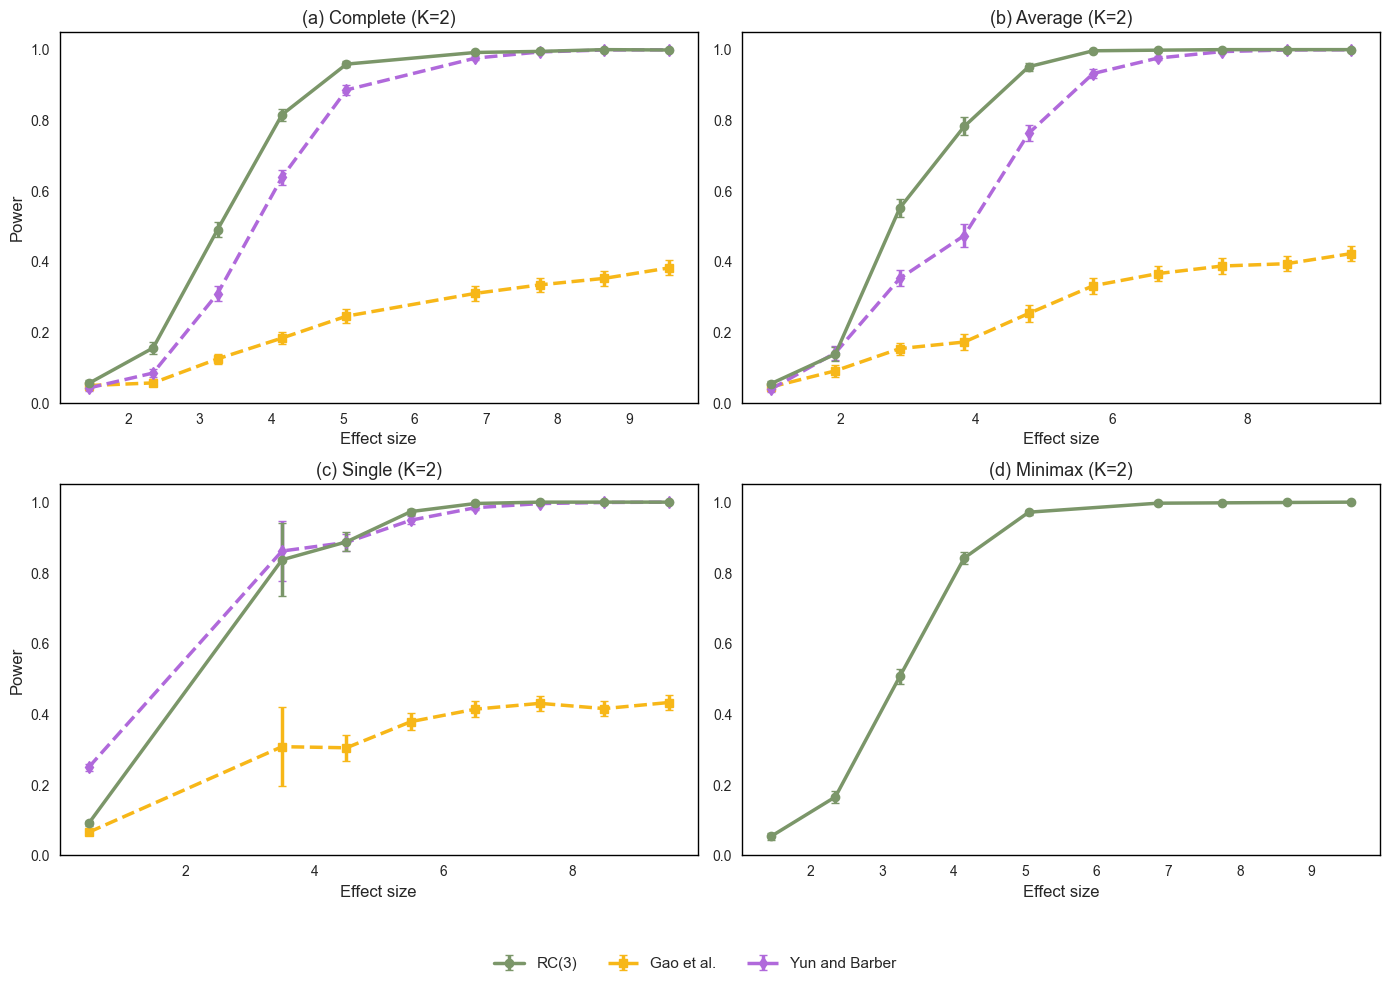

In [71]:
linkages = ["Complete", "Average", "Single", "Minimax"]
K = 2

colors = {"sel": "#7B9669", "gao": "#F7B718", "barber": "#B069DB"}

base_path = "../results/raw/fig6_es"
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
letters = ['(a)', '(b)', '(c)', '(d)']
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)
for i, linkage in enumerate(linkages):
    ax = axes[i]
    ax.set_title(f"{letters[i]} {linkage} (K={K})", fontsize=13)
    ax.set_xlabel("Effect size", fontsize=12)
    if i in (0, 2):
        ax.set_ylabel("Power", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.4)

    f_gao = f"{base_path}/rejection_es_gao_K{K}_{linkage}.csv"
    f_barber = f"{base_path}/rejection_es_barber_K{K}_{linkage}.csv"
    f_sel = f"{base_path}/reject_effect_size_K{K}_{linkage}.csv"

    if os.path.exists(f_gao):
        dfg = pd.read_csv(f_gao)
        bx, by, lo, up, _ = binned_empirical_power_with_ci_normal(dfg, n_bins=10, min_count=1, alpha=0.05)
        if len(bx) > 0:
            ax.errorbar(bx, by, yerr=[by - lo, up - by], fmt='s--', capsize=3,linewidth=2.5,
                        color=colors["gao"], label=r"Gao et al.")
    else:
        print(f"Missing Gao file for K={K}, {linkage}")

    if os.path.exists(f_barber):
        dfb = pd.read_csv(f_barber)
        bx, by, lo, up, _ = binned_empirical_power_with_ci_normal(dfb, n_bins=10, min_count=1, alpha=0.05)
        if len(bx) > 0:
            ax.errorbar(bx, by, yerr=[by - lo, up - by], fmt='d--', capsize=3,linewidth=2.5,
                        color=colors["barber"], label="Yun and Barber")
    else:
        print(f"Missing Barber file for K={K}, {linkage}")

    if os.path.exists(f_sel):
        dfr = pd.read_csv(f_sel)
        dfr = dfr[dfr["tau"] == 0.1]
        if not dfr.empty:
            bx, by, lo, up, _ = binned_empirical_power_with_ci_normal(dfr, n_bins=10, min_count=1, alpha=0.05)
            if len(bx) > 0:
                ax.errorbar(bx, by, yerr=[by - lo, up - by], fmt='o-', capsize=3,linewidth=2.5,
                            color=colors["sel"], label="RC(3)")
        else:
            print(f"No tau=0.1 data for K={K}, {linkage}")
    else:
        print(f"Missing RAC file for K={K}, {linkage}")

    if len(ax.lines) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center",
                fontsize=12, color="gray", transform=ax.transAxes)

    ax.set_ylim(0.0, 1.05)

desired_order = ["RC(3)", r"Gao et al.", "Yun and Barber"]
all_handles, all_labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    all_handles += h
    all_labels += l
unique = dict(zip(all_labels, all_handles))

legend_handles = [unique[x] for x in desired_order if x in unique]
legend_labels = [x for x in desired_order if x in unique]

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    fontsize=11,
    frameon=False
)
plt.savefig(
    "/Users/judydw/Desktop/slides-figs/sec3fig4.png",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T/ipykernel_45238/4093642874.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(abs(y))}" for y in yticks])
/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T/ipykernel_45238/4093642874.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(abs(y))}" for y in yticks])
/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T/ipykernel_45238/4093642874.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(abs(y))}" for y in yticks])
/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T/ipykernel_45238/4093642874.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usi

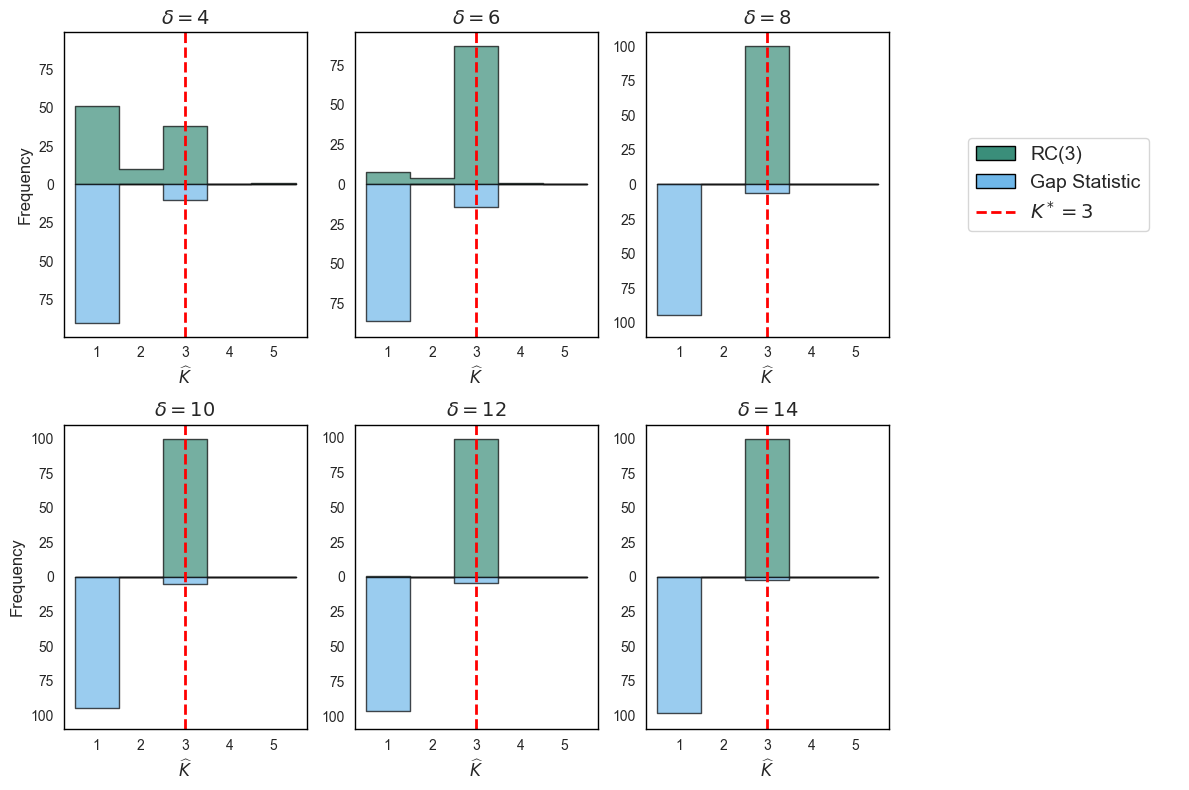

In [76]:
import glob

from matplotlib.lines import Line2D

n= 30
output_dir = os.path.join("../results/figures")
os.makedirs(output_dir, exist_ok=True)
files = glob.glob(f"../results/k_hat/k_hat_raw_{n}/*.csv")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
delta_list = [4,6,8,10,12,14]
df = df[df["delta"].isin(delta_list)]


fig, axes = plt.subplots(
2, 4,                     # 2 rows, 4 columns
figsize=(12, 8),
gridspec_kw={"width_ratios": [1, 1, 1, 1]}   # rightmost column is narrow legend panel
)

axes = axes.reshape(2, 4)
for ax in axes.flatten():
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.0)
# first 3 columns (0,1,2) are real plots
plot_axes = axes[:, :3].flatten()  # 6 axes in row-major order

# last column (col=3) are legend panels
legend_ax_top = axes[0, 3]
legend_ax_bottom = axes[1, 3]

# turn off both legend axes
legend_ax_top.axis("off")
legend_ax_bottom.axis("off")

Kmin = 1
Kmax = max(df["K_hat_F"].max(), df["K_hat_gap"].max())
bins = np.arange(Kmin - 0.5, Kmax + 1.5, 1)

for idx, delta in enumerate(delta_list):
    ax = plot_axes[idx]
    sub = df[df["delta"] == delta]

    # Proposed
    counts_F, edges = np.histogram(sub["K_hat_F"], bins=bins)
    ax.fill_between(
        edges.repeat(2)[1:-1],
        np.repeat(counts_F, 2),
        step="pre",
        alpha=0.7,
        color="#3A8E7A",
        edgecolor="black"
    )

    # Gap
    counts_G, _ = np.histogram(sub["K_hat_gap"], bins=bins)
    ax.fill_between(
        edges.repeat(2)[1:-1],
        -np.repeat(counts_G, 2),
        step="pre",
        alpha=0.7,
        color="#6FB7E9",
        edgecolor="black"
    )

    ax.axvline(3, color="red", linestyle="--", linewidth=2, label="True K = 3")

    ax.set_title(rf"$\delta = {delta}$", fontsize=14)
    ax.set_xticks(np.arange(Kmin, Kmax + 1))
    ax.set_xlabel(r"$\widehat{K}$", fontsize=12)

    ymax = max(counts_F.max(), counts_G.max())
    ax.set_ylim(-1.1 * ymax, 1.1 * ymax)

    if idx in [0, 3]:   # first column of each row
        ax.set_ylabel("Frequency", fontsize=12)

# ---- Legend in the top-right panel ----
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor="#3A8E7A", edgecolor="black", label="RC(3)"),
    Patch(facecolor="#6FB7E9", edgecolor="black", label="Gap Statistic")
]
trueK_handle = Line2D(
    [0], [0],
    color="red",
    linestyle="--",
    linewidth=2,
    label="$K^* = 3$"
)

legend_ax_top.legend(
    handles=legend_handles + [trueK_handle],
    loc="center",
    fontsize=14
)

# y-axis positive ticks
for ax in plot_axes:
    yticks = ax.get_yticks()
    ax.set_yticklabels([f"{int(abs(y))}" for y in yticks])

plt.tight_layout()
plt.savefig(
    "/Users/judydw/Desktop/slides-figs/sec4.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()
